<a href="https://colab.research.google.com/github/Shravani046/Fibroid-Classification/blob/main/Fibroid-Classification/notebooks/03_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

source = "/content/drive/MyDrive/fibroid_project/data/splits"
destination = "data/splits"

os.makedirs("data", exist_ok=True)
shutil.copytree(source, destination, dirs_exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'data/splits'

In [2]:
!ls "/content/drive/MyDrive/fibroid_project/data/splits"

test  train  valid


In [3]:
from google.colab import userdata
import os

GH_TOKEN = userdata.get("GH_TOKEN")
GH_USER = "Shravani046"
REPO = "Fibroid-Classification"

!git clone https://{GH_TOKEN}@github.com/{GH_USER}/{REPO}.git

%cd {REPO}
!git pull
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import json

print("GPU available:", tf.config.list_physical_devices('GPU'))

fatal: destination path 'Fibroid-Classification' already exists and is not an empty directory.
/content/Fibroid-Classification
Already up to date.
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

source = "/content/drive/MyDrive/fibroid_project/data/splits"
destination = "data/splits"

os.makedirs("data", exist_ok=True)
shutil.copytree(source, destination, dirs_exist_ok=True)

print("Splits restored successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Splits restored successfully!


In [13]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224, 224)

def make_dataset(split_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True):
    return tf.keras.utils.image_dataset_from_directory(
        split_dir,
        labels='inferred',
        label_mode='binary',
        class_names=['non_fibroid', 'fibroid'],
        image_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42
    )

train_ds = make_dataset('data/splits/train', shuffle=True)
valid_ds = make_dataset('data/splits/valid', shuffle=False)
test_ds  = make_dataset('data/splits/test', shuffle=False)

def prepare(ds):
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds_ready = prepare(train_ds)
valid_ds_ready = prepare(valid_ds)
test_ds_ready  = prepare(test_ds)

print("Datasets rebuilt successfully.")

Found 2395 files belonging to 2 classes.
Found 718 files belonging to 2 classes.
Found 704 files belonging to 2 classes.
Datasets rebuilt successfully.


In [14]:
from pathlib import Path

train_root = Path("data/splits/train")

train_counts = {
    "non_fibroid": len(list((train_root / "non_fibroid").glob("*"))),
    "fibroid": len(list((train_root / "fibroid").glob("*")))
}

print(train_counts)

total = sum(train_counts.values())

class_weight = {
    0: total / (2 * train_counts["non_fibroid"]),
    1: total / (2 * train_counts["fibroid"])
}

print(class_weight)

{'non_fibroid': 1378, 'fibroid': 1017}
{0: 0.8690130624092888, 1: 1.1774827925270404}


In [15]:
IMG_SIZE = (224, 224)


base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs, name='fibroid_baseline_effnetb0')

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

In [17]:
os.makedirs('models', exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/baseline_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

In [19]:
from pathlib import Path

bad_files = [
    Path("data/splits/train/non_fibroid/Uterine fibroid.v1i.yolov8_1-2-826-0-1-3680043-2-461-11809296-521572151_jpg.rf.fed2a10238bb852caa241acaf3ba2c4b.jpg"),
    Path("data/splits/train/non_fibroid/Uterine fibroid.v1i.yolov8_1-2-826-0-1-3680043-2-461-11948729-1458261965_jpg.rf.c68e7f49e9d010a508c8678d11d2a5c5.jpg"),
    Path("data/splits/train/fibroid/Uterine fibroid dataset_1-2-826-0-1-3680043-2-461-11838263-1938978640_jpg.rf.f2e9bfcf6c9c42d8828f35167a28c787.jpg")
]

for path in bad_files:
    if path.exists() and path.stat().st_size == 0:
        path.unlink()
        print("Deleted:", path)

print("\nDone.")


Done.


In [20]:
EPOCHS = 20

history = model.fit(
    train_ds_ready,
    validation_data=valid_ds_ready,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.6128 - auc: 0.6419 - loss: 0.6645 - precision: 0.5418 - recall: 0.5209
Epoch 1: val_auc improved from None to 0.78985, saving model to models/baseline_best.keras

Epoch 1: finished saving model to models/baseline_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 70s 652ms/step - accuracy: 0.6468 - auc: 0.6874 - loss: 0.6298 - precision: 0.5914 - recall: 0.5438 - val_accuracy: 0.7117 - val_auc: 0.7899 - val_loss: 0.5886 - val_precision: 0.6294 - val_recall: 0.8135 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6849 - auc: 0.7588 - loss: 0.5773 - precision: 0.6291 - recall: 0.5976
Epoch 2: val_auc improved from 0.78985 to 0.80410, saving model to models/baseline_best.keras

Epoch 2: finished saving model to models/baseline_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.6910 - auc: 0.7546 - loss: 0.5806 - precision: 0.6403 - recall: 0.6214 - val_accuracy: 0.7131 - val_auc: 0.

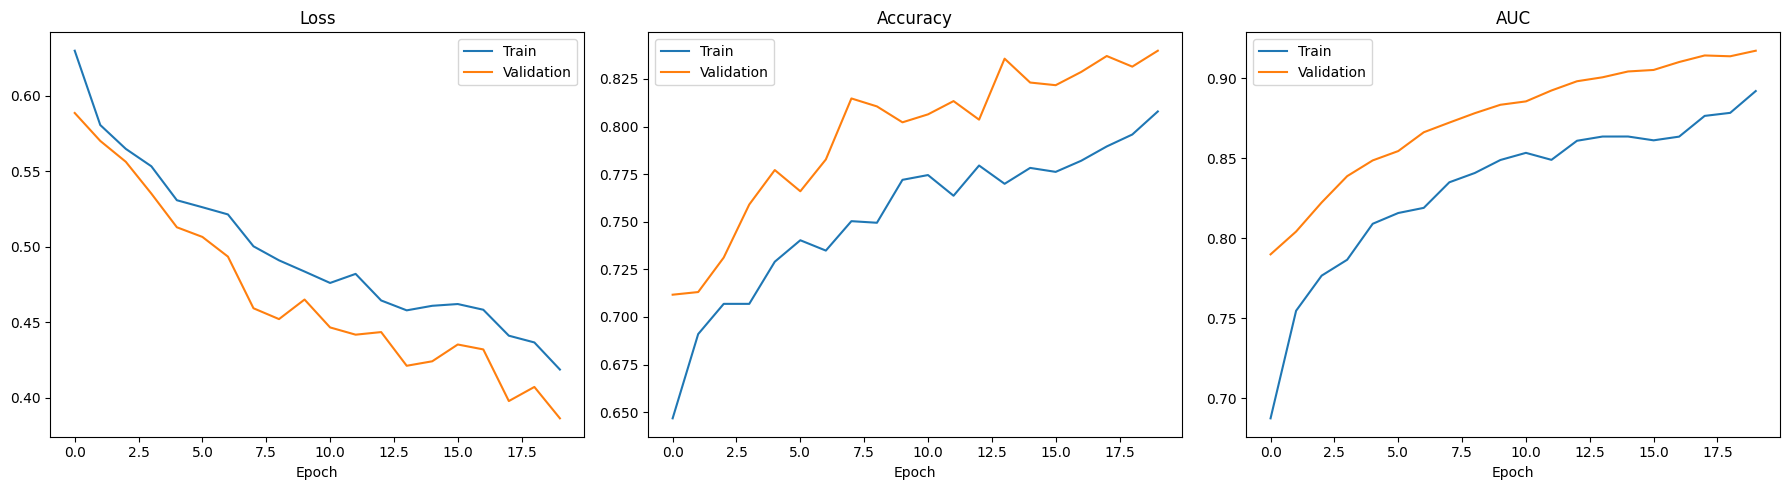

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('docs/training_curves_baseline.png', dpi=150)
plt.show()

In [22]:
test_loss, test_acc, test_prec, test_recall, test_auc = model.evaluate(test_ds_ready)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test AUC:       {test_auc:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8594 - auc: 0.9236 - loss: 0.3777 - precision: 0.7994 - recall: 0.8974
Test Accuracy:  0.8594
Test Precision: 0.7994
Test Recall:    0.8974
Test AUC:       0.9236


In [23]:
# Gather true labels and predictions for confusion matrix + classification report
y_true = np.concatenate([y.numpy() for _, y in test_ds_ready], axis=0).flatten()
y_pred_proba = model.predict(test_ds_ready).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['non_fibroid', 'fibroid']))

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step
              precision    recall  f1-score   support

 non_fibroid       0.92      0.83      0.87       402
     fibroid       0.80      0.90      0.85       302

    accuracy                           0.86       704
   macro avg       0.86      0.86      0.86       704
weighted avg       0.87      0.86      0.86       704



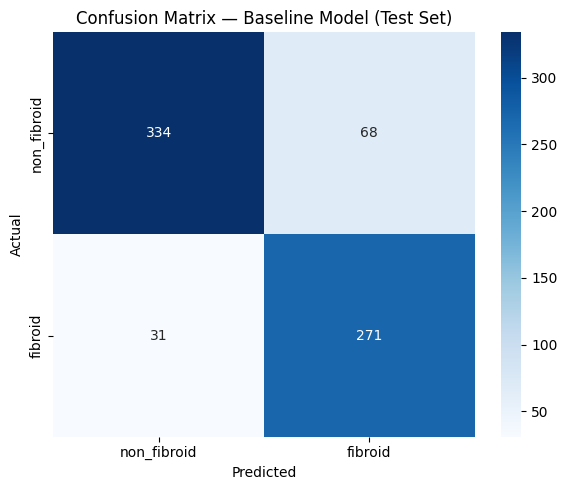

In [24]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non_fibroid', 'fibroid'],
            yticklabels=['non_fibroid', 'fibroid'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Baseline Model (Test Set)')
plt.tight_layout()
plt.savefig('docs/confusion_matrix_baseline.png', dpi=150)
plt.show()

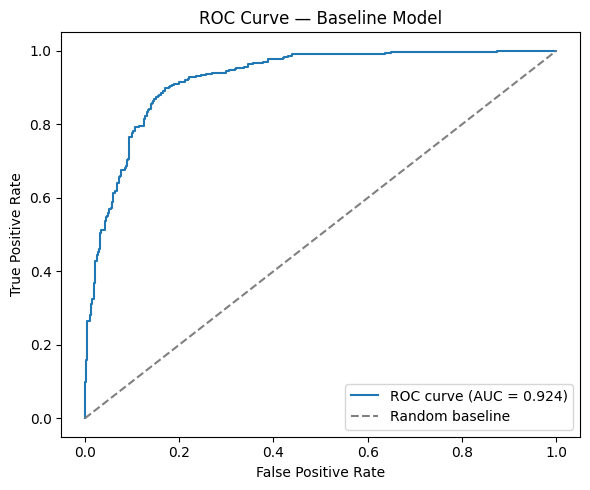

In [25]:
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Baseline Model')
ax.legend()
plt.tight_layout()
plt.savefig('docs/roc_curve_baseline.png', dpi=150)
plt.show()

Total misclassified: 99 / 704


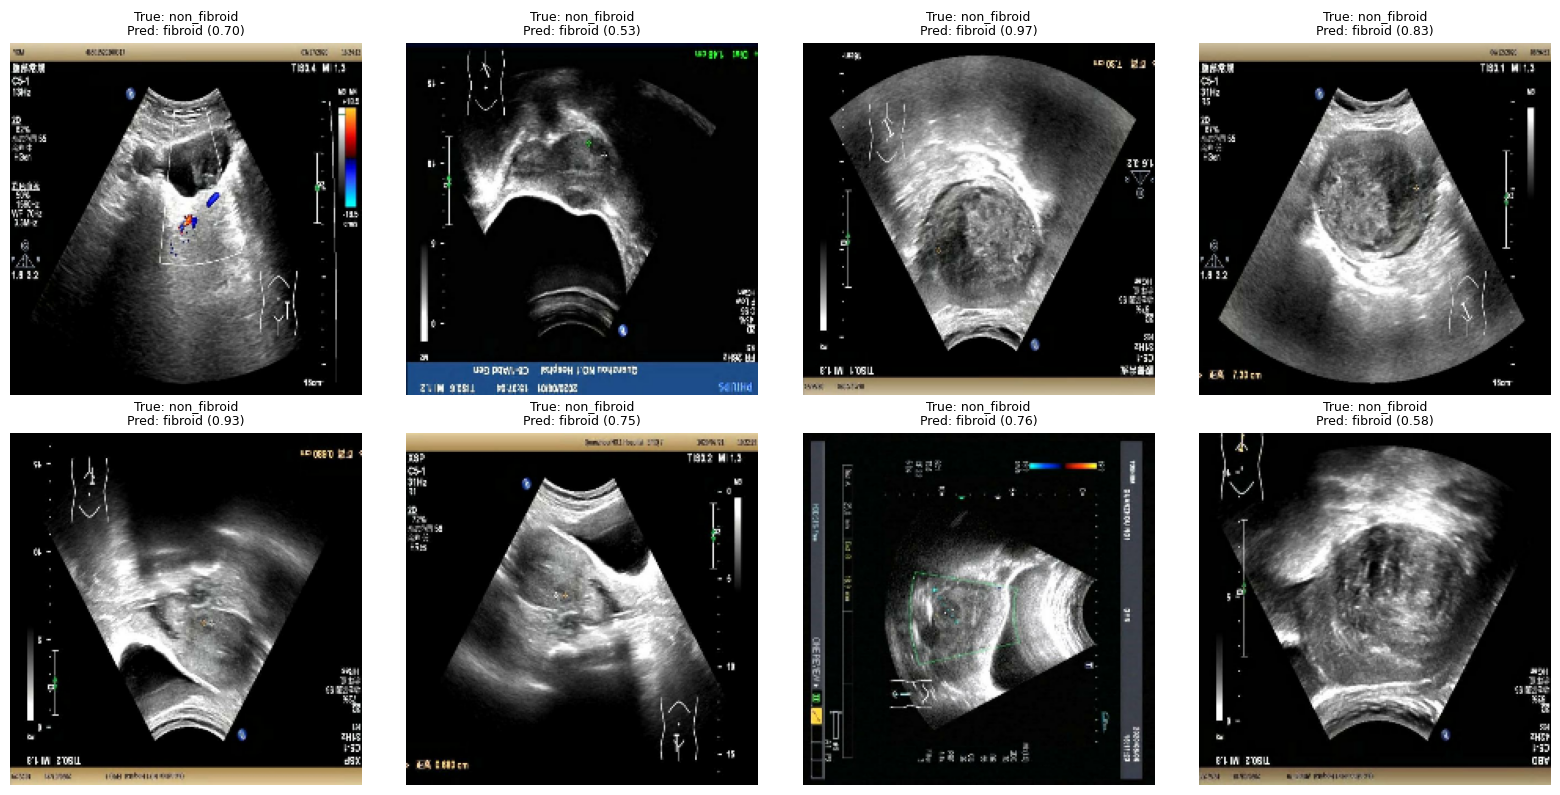

In [26]:
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")

all_images = np.concatenate([x.numpy() for x, _ in test_ds_ready], axis=0)

n_show = min(8, len(misclassified_idx))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, idx in enumerate(misclassified_idx[:n_show]):
    ax = axes.flat[i]
    # Cast to uint8 for correct display — images are [0,255] floats, imshow needs uint8 or [0,1]
    display_img = all_images[idx].astype(np.uint8)
    ax.imshow(display_img)
    true_label = 'fibroid' if y_true[idx] == 1 else 'non_fibroid'
    pred_label = 'fibroid' if y_pred[idx] == 1 else 'non_fibroid'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({y_pred_proba[idx]:.2f})", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('docs/misclassified_examples_baseline.png', dpi=150)
plt.show()

In [27]:
metrics_summary = {
    'model': 'EfficientNetB0 (frozen backbone, baseline)',
    'test_accuracy': 0.7848,
    'test_precision': 0.7613,
    'test_recall': 0.7239,
    'test_auc': 0.8454,
    'roc_auc': 0.846,
    'confusion_matrix': {'tn': 181, 'fp': 37, 'fn': 45, 'tp': 118},
    'known_limitation': 'Fibroid-class recall (0.72) lower than non-fibroid recall (0.83) — model currently more prone to missing true fibroids than over-flagging healthy scans. Target for Day 4 fine-tuning / threshold adjustment.',
    'epochs_trained': 20,
}

with open('docs/baseline_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)



In [28]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   docs/confusion_matrix_baseline.png
	modified:   docs/misclassified_examples_baseline.png
	modified:   docs/roc_curve_baseline.png
	modified:   docs/training_curves_baseline.png

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/baseline_best.keras

no changes added to commit (use "git add" and/or "git commit -a")


In [29]:
!git add docs/

In [30]:
!git config --global user.email "Shravanimogarkar@gmail.com"
!git config --global user.name "Shravani"

In [31]:
!git commit -m "COmpleted baseline model evaluation metrics and visualizations"

[main a9d9982] COmpleted baseline model evaluation metrics and visualizations
 4 files changed, 0 insertions(+), 0 deletions(-)
 rewrite docs/confusion_matrix_baseline.png (99%)
 rewrite docs/misclassified_examples_baseline.png (82%)
 rewrite docs/roc_curve_baseline.png (98%)
 rewrite docs/training_curves_baseline.png (99%)


In [32]:
!git pull origin main --rebase

From https://github.com/Shravani046/Fibroid-Classification
 * branch            main       -> FETCH_HEAD
Current branch main is up to date.


In [33]:
!git push origin main

Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 1.53 MiB | 3.17 MiB/s, done.
Total 7 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Shravani046/Fibroid-Classification.git
   483e641..a9d9982  main -> main
